<a target="_blank" href="https://colab.research.google.com/github/seap-udea/fargopy/blob/main/examples/fargopy-tutorial-animations.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<p align="left"><img src="https://github.com/seap-udea/fargopy/raw/refactor/docs/fargopy_logo.webp" width="300" /></p>

# Tutorial: basics of FARGOpy

In [1]:
try:
    from google.colab import drive
    %pip install -Uq git+https://github.com/seap-udea/fargopy
except ImportError:
    print("Not running in Colab, skipping installation")
    %load_ext autoreload
    %autoreload 2
!mkdir -p ./gallery/


Not running in Colab, skipping installation


If you are in `Google Colab`, install the latest version of the package:

For this tutorial you will need the following external modules and tools:

In [2]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
from celluloid import Camera
from IPython.display import HTML
from tqdm import tqdm

Your configuration file version '1.0.8' it is different than the installed version of FARGOpy '1.0.9'
Running FARGOpy version 1.0.9


### Let's `FARGOpy`

First we need the data. Let's download a precomputed simulation. Check the list:

In [3]:
fp.Simulation.list_precomputed()

fargo:
	Description: Protoplanetary disk with a Jovian planet [2D]
	Size: 55 MB
p3diso:
	Description: Protoplanetary disk with a Super earth planet [3D]
	Size: 220 MB
p3disoj:
	Description: Protoplanetary disk with a Jovian planet [3D]
	Size: 84 MB
fargo_multifluid:
	Description: Protoplanetary disk with several fluids (dust) and a Jovian planet in 2D
	Size: 100 MB
binary:
	Description: Disk around a binary with the properties of Kepler-38 in 2D
	Size: 140 MB
pds70iso:
	Description: PDS-70c - isothermal protoplanetary disk and circumplanetary disk in [3D]
	Size: 2940 MB


Download, for instance, the 2D simulation of a disk with a Jovian planet:

In [11]:
simpath = fp.Simulation.download_precomputed('p3disoj')

Precomputed output directory '/tmp/p3disoj' already exist


Once download it, we need to connect a `Simulation` with the directory with the simulation results:

In [65]:
sim = fp.Simulation(output_dir=simpath)

Your simulation is now connected with '/Users/jzuluaga/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat:
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


Let's read the field we want to animate, eg. the gas density. It is important to notice that we will animate the field in a slice corresponding to $z=0$:

In [85]:
fields_spherical = sim.load_field(
    fields='gasdens',
    snapshot=[1, sim.nsnaps-1],
    coords='spherical',
    slice='theta=1.56'
)

fields_cartesian = sim.load_field(
    fields='gasdens',
    snapshot=[1, sim.nsnaps-1],
    coords='cartesian',
    slice='theta=1.56'
)

And the plot can be done using:

In [86]:
snapshot = 5

phi = fields_spherical.var1_mesh[snapshot]
r = fields_spherical.var2_mesh[snapshot]

x = fields_cartesian.var1_mesh[snapshot]
y = fields_cartesian.var2_mesh[snapshot]

gasdens_plane = fields_cartesian.gasdens_mesh[snapshot]

x.shape, y.shape, gasdens_plane.shape, r.shape, phi.shape

((64, 128), (64, 128), (64, 128), (64, 128), (64, 128))

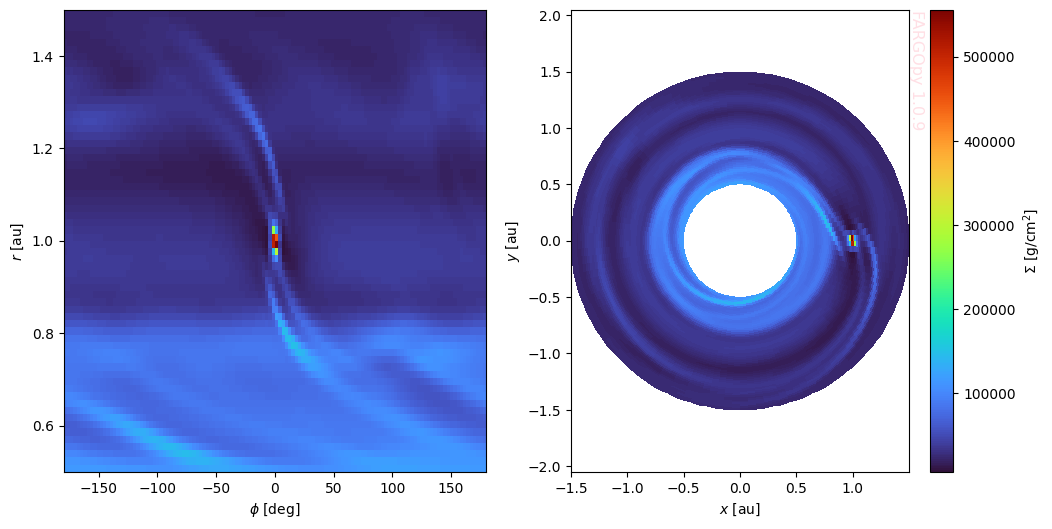

In [87]:
plt.close('all')
fig,axs = plt.subplots(1,2,figsize=(12,6))
cmap = 'turbo'

ax = axs[0]
ax.pcolormesh(phi*fp.RAD,r*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
ax.set_xlabel('$\phi$ [deg]')
ax.set_ylabel('$r$ [au]')

ax = axs[1]
c = ax.pcolormesh(x*sim.UL/fp.AU,y*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$y$ [au]')
ax.axis('equal')
fp.Plot.fargopy_mark(ax, frac=1/4)

axc = fig.colorbar(c)
axc.set_label("$\Sigma$ [g/cm$^2$]")
plt.savefig('gallery/fargopy-tutorial-animations_0.png') # Save figure


Notice that we have used the units of the simulation to convert all quantities from simulation units to physical units.

Now, to create the animation we repeat the previous procedure at each snapshot:

In [88]:
plt.ioff()
fig,axs = plt.subplots(1,2,figsize=(12,6))
cmap = 'turbo'

# Create a Celluloid camera
camera = Camera(fig)

for snapshot in tqdm(range(sim.nsnaps-1)):
    # For each snapshot get the desnity and meshslice it
    phi = fields_spherical.var1_mesh[snapshot]
    r = fields_spherical.var2_mesh[snapshot]
    x = fields_cartesian.var1_mesh[snapshot]
    y = fields_cartesian.var2_mesh[snapshot]
    gasdens_plane = fields_cartesian.gasdens_mesh[snapshot]

    ax = axs[0]
    ax.pcolormesh(phi*fp.RAD,r*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
    ax.set_xlabel('$\phi$ [deg]')
    ax.set_ylabel('$r$ [au]')

    ax = axs[1]
    c = ax.pcolormesh(x*sim.UL/fp.AU,y*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
    ax.set_xlabel('$x$ [au]')
    ax.set_ylabel('$y$ [au]')
    ax.axis('equal')
    fp.Plot.fargopy_mark(ax)

    # Take a snapshot of the figure
    camera.snap()

# Create the animation object
animation = camera.animate()
plt.ion()
plt.savefig('gallery/fargopy-tutorial-animations_1.png') # Save figure
animation.save('gallery/fargopy-tutorial-animations_2.gif', writer='pillow') # Save animation


100%|██████████| 10/10 [00:00<00:00, 288.47it/s]


Once you have snapped all the frames we can create the animation, save it and/or visualize it:

In [89]:
HTML(animation.to_html5_video())

Save it into a gif:

In [90]:
animation.save('gallery/fargo.gif', fps=5)

And that's it!

### Animations preview

Since the animations in this notebook will not be displayed on the web we include here the animation figures which are available in the `GitHub` repository:

<p align="center"><img src="https://raw.githubusercontent.com/seap-udea/fargopy/main/gallery/fargo-animation.gif" alt="Animation""/></p>

---
*Powered by fargopy*. For more examples see [fargopy GitHub repo](https://github.com/seap-udea/fargopy/tree/main/examples). 

Jorge I. Zuluaga, Alejandro Murillo-González and Matías Montesinos © 2023-present
